# 07. Health, Education, and Policy Applications

Health, education, and public policy problems make causal inference feel different from product analytics.

The stakes are higher. Outcomes are slower. Randomization may be ethically or politically constrained. Data may come from administrative systems with more friction than clean product logs. Compliance is often imperfect. The final decision is rarely "ship the feature"; it may be "expand the program", "change eligibility", "fund the intervention", "continue the pilot", or "protect a subgroup from harm".

This notebook treats applied policy evaluation as a causal decision workflow. We will study:

- a health coverage lottery with imperfect take-up,
- an education regression discontinuity around an eligibility cutoff,
- a staggered policy rollout with event-study diagnostics,
- equity and cost-effectiveness readouts,
- a final decision memo that distinguishes evidence from recommendation.


## Learning Goals

By the end of this notebook, you should be able to:

- Translate health, education, and policy questions into explicit causal estimands.
- Distinguish intention-to-treat effects from treatment-on-treated and local average treatment effects.
- Use instrumental variables when randomized assignment changes treatment take-up imperfectly.
- Estimate and interpret regression discontinuity effects around eligibility cutoffs.
- Analyze staggered policy rollouts with fixed effects and event-study diagnostics.
- Add equity, cost, and implementation constraints to causal readouts.
- Write policy-facing conclusions that are honest about internal validity, external validity, and residual risk.


## 1. Setup

We will use pandas, numpy, scipy, statsmodels, seaborn, matplotlib, and Graphviz.


In [1]:
# Import the analysis, modeling, and plotting tools used throughout this notebook.
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import expit
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 90)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def regression_effect(model, term):
    """Compute regression effect for the health education and policy applications example.
    
    Inputs:
    - `model`: fitted statistical or machine-learning model whose coefficients or predictions are being used.
    - `term`: coefficient name whose estimate and uncertainty should be extracted.
    Returns: an effect-estimate summary for the causal comparison in the section."""
    estimate = model.params[term]
    se = model.bse[term]
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
            "p_value": model.pvalues[term],
        }
    )


def plot_coef_table(table, title, xlabel, reference=0, figsize=(8, 4)):
    """Plot the coef table display.
    
    Inputs:
    - `table`: estimate table with columns such as estimate, standard error, and confidence limits.
    - `title`: plot or graph title displayed above the figure.
    - `xlabel`: x-axis label used in the estimate plot.
    - `reference`: reference value shown as a vertical line, often the true or benchmark effect.
    - `figsize`: Matplotlib figure size passed to the plotting function.
    Returns: a Matplotlib figure or axes object that visualizes the causal estimates."""
    plot_df = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        x=plot_df["estimate"],
        y=plot_df.index,
        xerr=[
            plot_df["estimate"] - plot_df["ci_lower"],
            plot_df["ci_upper"] - plot_df["estimate"],
        ],
        fmt="o",
        color="#2b8cbe",
        ecolor="#a6bddb",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    return fig, ax


### Dataset and Experiment Setup

This notebook uses stylized health, education, and policy examples. The units include patients, students, schools, regions, or eligible program participants. Treatments include lottery assignment, tutoring access, policy rollout, and eligibility around a threshold. Outcomes include health, achievement, service use, or program-relevant performance measures.

These examples are synthetic because the goal is to teach design logic. Health, education, and policy data are often sensitive, hard to share, and rarely contain verified counterfactual outcomes. The simulations let the notebook show how lotteries, regression discontinuities, take-up, baseline risk, thresholds, and implementation timing shape causal interpretation. The realism comes from imperfect compliance, eligibility rules, heterogeneous baseline risk, and institutional timing, while the known data-generating process keeps the identification lesson visible.


## 2. Why Policy Causal Inference Is Hard

In product experimentation, the intervention is often a feature flag. In policy work, the intervention is often a program, benefit, rule, service model, eligibility threshold, or institutional change.

Policy evaluations have recurring complications:

- the people who receive services may be selected because they need them most,
- program assignment may be randomized but actual take-up may not be,
- outcomes can be delayed, rare, or expensive to measure,
- the intervention may have spillovers through families, schools, providers, or neighborhoods,
- ethical constraints may limit who can be assigned to control,
- external validity matters because the decision is usually about scaling beyond the study setting.

Deaton and Cartwright (2018) argue that randomized trials should be interpreted with realistic expectations about what they do and do not guarantee. The same caution applies to quasi-experiments: a credible design helps answer a specific causal question, not every policy question.


### Mathematical Core: ITT, LATE, RD, and Rollout Designs

Policy evaluations often begin with an assignment or eligibility variable $Z$, not with perfect treatment receipt. The intention-to-treat effect is:

$$
ITT = E[Y\mid Z=1]-E[Y\mid Z=0].
$$

If assignment changes take-up $D$, the first stage is:

$$
FS = E[D\mid Z=1]-E[D\mid Z=0].
$$

Under the instrumental-variable assumptions, the local average treatment effect for compliers is the Wald ratio:

$$
LATE = \frac{E[Y\mid Z=1]-E[Y\mid Z=0]}{E[D\mid Z=1]-E[D\mid Z=0]}.
$$

For a regression discontinuity with running variable $R$ and cutoff $c$, the local estimand is:

$$
\tau_{RD}=\lim_{r\downarrow c}E[Y\mid R=r]-\lim_{r\uparrow c}E[Y\mid R=r].
$$

For a rollout or difference-in-differences design, the core estimand compares changes:

$$
\tau_{DiD}=E[Y_{post}-Y_{pre}\mid treated]-E[Y_{post}-Y_{pre}\mid control].
$$

These formulas correspond to different policy questions. ITT measures the effect of offering or assigning access. LATE measures the effect for people induced to take treatment by assignment. RD is local to the cutoff. DiD relies on parallel trends in untreated potential outcomes.


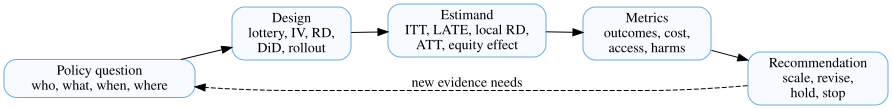

In [2]:
dot = Digraph("policy_workflow", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("Q", "Policy question\nwho, what, when, where")
dot.node("D", "Design\nlottery, IV, RD,\nDiD, rollout")
dot.node("E", "Estimand\nITT, LATE, local RD,\nATT, equity effect")
dot.node("M", "Metrics\noutcomes, cost,\naccess, harms")
dot.node("R", "Recommendation\nscale, revise,\nhold, stop")

dot.edge("Q", "D")
dot.edge("D", "E")
dot.edge("E", "M")
dot.edge("M", "R")
dot.edge("R", "Q", label="new evidence needs", style="dashed")

dot


This is where the calculation starts to matter for the decision. Policy evidence has to connect effects to access, compliance, equity, and the population that will use the recommendation.

## 3. A Policy Metric Stack

Health, education, and policy projects should avoid single-number thinking. The primary outcome matters, but so do access, equity, costs, implementation quality, and harms.


| domain | primary_metric | equity_question | cost_question |
|---|---|---|---|
| Health | Preventive care, clinical risk, utilization, quality of life | Did access improve for the groups facing the largest barriers? | Did the program shift cost, reduce avoidable utilization, or improve value? |
| Education | Learning gains, attendance, graduation, persistence | Did the intervention reduce gaps or only raise averages? | Are gains large relative to staff time, tutoring hours, or class capacity? |
| Labor and social policy | Employment, earnings, housing stability, benefit take-up | Who is screened out, discouraged, sanctioned, or burdened? | Do administrative and participant costs change the value calculation? |
| Public safety and civic systems | Incidents, compliance, service timeliness, trust | Are impacts different across neighborhoods or demographic groups? | Do benefits justify enforcement, monitoring, or service delivery costs? |


## 4. Example 1: Health Coverage Lottery With Imperfect Take-Up

Suppose a state has funds to offer a health coverage program to some eligible low-income adults. Demand exceeds available slots, so the state runs a lottery. Lottery winners are allowed to apply, but not everyone who wins completes enrollment. Some people who lose the lottery obtain coverage through other paths.

This resembles the logic of the Oregon Health Insurance Experiment, where Oregon used a lottery to allocate a limited Medicaid expansion opportunity. Baicker et al. (2013) describe how the lottery created randomized assignment, while actual Medicaid coverage required an instrumental-variables approach because not all selected individuals enrolled.

We will simulate a simplified version.


In [4]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_health_lottery(seed=101, n=9000):
    """Simulate the health lottery data-generating process.
    
    Inputs:
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    - `n`: number of simulated units or records to generate for the teaching example.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)

    age = rng.integers(19, 65, size=n)
    female = rng.binomial(1, 0.56, size=n)
    chronic = rng.binomial(1, expit(-1.2 + 0.035 * (age - 40)), size=n)
    income_pct_fpl = np.clip(rng.normal(95, 28, size=n), 15, 180)
    baseline_visits = rng.poisson(np.exp(-0.25 + 0.55 * chronic + 0.012 * (age - 40)), size=n)
    region = rng.choice(["North", "South", "East", "West"], size=n, p=[0.25, 0.28, 0.22, 0.25])
    high_barrier = rng.binomial(1, expit(0.65 - 0.018 * income_pct_fpl + 0.25 * chronic), size=n)

    lottery = rng.binomial(1, 0.42, size=n)
    p_coverage_if_lose = expit(-3.0 + 0.18 * chronic + 0.006 * income_pct_fpl)
    p_coverage_if_win = expit(-0.35 + 0.35 * chronic - 0.010 * income_pct_fpl - 0.45 * high_barrier)
    coverage_prob = np.where(lottery == 1, p_coverage_if_win, p_coverage_if_lose)
    coverage = rng.binomial(1, coverage_prob)

    latent_health = (
        58
        - 0.18 * (age - 40)
        - 6.0 * chronic
        + 0.035 * income_pct_fpl
        - 2.0 * high_barrier
        + rng.normal(0, 4, size=n)
    )

    true_coverage_effect = 4.0 + 1.2 * chronic + 0.8 * high_barrier
    health_score = latent_health + true_coverage_effect * coverage + rng.normal(0, 5, size=n)
    preventive_visit = rng.binomial(
        1,
        expit(-1.00 + 0.95 * coverage + 0.35 * chronic - 0.20 * high_barrier),
        size=n,
    )
    outpatient_visits = rng.poisson(
        np.exp(-0.15 + 0.36 * coverage + 0.45 * chronic + 0.08 * baseline_visits),
        size=n,
    )
    emergency_visits = rng.poisson(
        np.exp(-1.45 - 0.22 * coverage + 0.65 * chronic + 0.20 * high_barrier),
        size=n,
    )
    out_of_pocket_cost = np.clip(
        rng.normal(620 + 230 * chronic + 90 * high_barrier - 280 * coverage, 190, size=n),
        0,
        None,
    )

    return pd.DataFrame(
        {
            "age": age,
            "female": female,
            "chronic": chronic,
            "income_pct_fpl": income_pct_fpl,
            "baseline_visits": baseline_visits,
            "region": region,
            "high_barrier": high_barrier,
            "lottery": lottery,
            "coverage": coverage,
            "health_score": health_score,
            "preventive_visit": preventive_visit,
            "outpatient_visits": outpatient_visits,
            "emergency_visits": emergency_visits,
            "out_of_pocket_cost": out_of_pocket_cost,
        }
    )


df_health = simulate_health_lottery()
df_health.head()


,age,female,chronic,income_pct_fpl,baseline_visits,region,high_barrier,lottery,coverage,health_score,preventive_visit,outpatient_visits,emergency_visits,out_of_pocket_cost
0,33,0,0,134.463,1,South,0,1,1,67.984,0,0,1,451.727
1,62,0,1,68.270,3,South,0,1,0,55.127,1,3,1,612.640
2,51,1,0,94.652,2,West,0,1,0,45.674,0,2,0,569.650
3,35,0,0,150.147,1,West,0,1,0,66.540,0,3,0,567.644
4,25,1,0,100.819,0,East,0,0,0,53.417,0,2,1,575.600


The lottery is randomized. Coverage is not. Coverage is affected by paperwork, eligibility verification, barriers to enrollment, and outside coverage options.

This creates three distinct estimands:

- **ITT:** effect of winning the lottery, regardless of whether the person enrolls.
- **First stage:** effect of winning the lottery on coverage.
- **LATE:** effect of coverage among compliers, estimated using lottery assignment as an instrument.

The Wald estimand is:

$$
LATE = \frac{E[Y \mid Z=1] - E[Y \mid Z=0]}{E[D \mid Z=1] - E[D \mid Z=0]}
$$

where $Z$ is lottery assignment and $D$ is actual coverage.


In [5]:
balance_table = (
    df_health.groupby("lottery")
    .agg(
        n=("lottery", "size"),
        age=("age", "mean"),
        chronic=("chronic", "mean"),
        income_pct_fpl=("income_pct_fpl", "mean"),
        baseline_visits=("baseline_visits", "mean"),
        high_barrier=("high_barrier", "mean"),
    )
    .rename(index={0: "Lottery control", 1: "Lottery winner"})
)
balance_table.loc["Difference"] = balance_table.loc["Lottery winner"] - balance_table.loc["Lottery control"]
balance_table


,n,age,chronic,income_pct_fpl,baseline_visits,high_barrier
lottery,,,,,,
Lottery control,"5,210.000",41.461,0.249,95.189,0.962,0.279
Lottery winner,"3,790.000",41.439,0.259,95.400,0.975,0.272
Difference,"-1,420.000",-0.022,0.010,0.211,0.013,-0.008


The pre-treatment variables are balanced up to random noise. That gives the lottery assignment a causal interpretation. It does not make actual coverage as-if randomized.

policy evidence should connect effects to access, compliance, equity, and the population where the recommendation will be used.

In [6]:
coverage_by_lottery = (
    df_health.groupby("lottery")["coverage"]
    .agg(["mean", "count"])
    .rename(index={0: "Lottery control", 1: "Lottery winner"})
)
first_stage_raw = coverage_by_lottery.loc["Lottery winner", "mean"] - coverage_by_lottery.loc["Lottery control", "mean"]

coverage_by_lottery, first_stage_raw


(                 mean  count
 lottery                     
 Lottery control 0.083   5210
 Lottery winner  0.216   3790,
 np.float64(0.13286555690041985))

The first stage is large: winning the lottery substantially increases coverage probability. A weak first stage would make an IV estimate unstable and hard to interpret.

policy evidence should connect effects to access, compliance, equity, and the population where the recommendation will be used.

In [7]:
outcome_list = [
    "health_score",
    "preventive_visit",
    "outpatient_visits",
    "emergency_visits",
    "out_of_pocket_cost",
]

itt_rows = []
for outcome in outcome_list:
    model = smf.ols(
        f"{outcome} ~ lottery + age + female + chronic + income_pct_fpl + baseline_visits + high_barrier + C(region)",
        data=df_health,
    ).fit(cov_type="HC1")
    row = regression_effect(model, "lottery")
    row["outcome"] = outcome
    itt_rows.append(row)

itt_table = pd.DataFrame(itt_rows).set_index("outcome")
itt_table


,estimate,std_error,ci_lower,ci_upper,p_value
outcome,,,,,
health_score,0.626,0.141,0.350,0.902,0.000
preventive_visit,0.043,0.010,0.024,0.063,0.000
outpatient_visits,0.106,0.024,0.059,0.152,0.000
emergency_visits,-0.017,0.012,-0.040,0.006,0.140
out_of_pocket_cost,-39.220,4.548,-48.135,-30.306,0.000


The ITT answers a program access question: what is the effect of being offered the chance to enroll?

For policy operations, ITT is often the most honest estimate of the program as implemented. If paperwork barriers prevent enrollment, the ITT includes that implementation reality.


In [8]:
wald_rows = []
for outcome in outcome_list:
    y1 = df_health.loc[df_health["lottery"] == 1, outcome].mean()
    y0 = df_health.loc[df_health["lottery"] == 0, outcome].mean()
    d1 = df_health.loc[df_health["lottery"] == 1, "coverage"].mean()
    d0 = df_health.loc[df_health["lottery"] == 0, "coverage"].mean()
    itt = y1 - y0
    first_stage = d1 - d0
    late = itt / first_stage
    wald_rows.append(
        {
            "outcome": outcome,
            "itt_raw": itt,
            "first_stage": first_stage,
            "wald_late": late,
        }
    )

wald_table = pd.DataFrame(wald_rows).set_index("outcome")
wald_table


,itt_raw,first_stage,wald_late
outcome,,,
health_score,0.589,0.133,4.431
preventive_visit,0.045,0.133,0.335
outpatient_visits,0.113,0.133,0.851
emergency_visits,-0.016,0.133,-0.117
out_of_pocket_cost,-37.786,0.133,-284.396


The LATE answers a different question: among people whose coverage status was changed by the lottery, what was the effect of coverage?

Angrist, Imbens, and Rubin (1996) formalized this local average treatment effect interpretation for instrumental variables. Imbens (2014) reviews the IV logic and emphasizes that the LATE is a real but local estimand.


In [9]:
first_stage_model = smf.ols(
    "coverage ~ lottery + age + female + chronic + income_pct_fpl + baseline_visits + high_barrier + C(region)",
    data=df_health,
).fit(cov_type="HC1")

df_health = df_health.assign(coverage_hat=first_stage_model.fittedvalues)

iv_health_model = smf.ols(
    "health_score ~ coverage_hat + age + female + chronic + income_pct_fpl + baseline_visits + high_barrier + C(region)",
    data=df_health,
).fit(cov_type="HC1")

naive_health_model = smf.ols(
    "health_score ~ coverage + age + female + chronic + income_pct_fpl + baseline_visits + high_barrier + C(region)",
    data=df_health,
).fit(cov_type="HC1")

iv_comparison = pd.DataFrame(
    {
        "Naive adjusted coverage coefficient": regression_effect(naive_health_model, "coverage"),
        "Teaching 2SLS point estimate": regression_effect(iv_health_model, "coverage_hat"),
        "First stage lottery coefficient": regression_effect(first_stage_model, "lottery"),
    }
).T

iv_comparison


,estimate,std_error,ci_lower,ci_upper,p_value
Naive adjusted coverage coefficient,4.807,0.191,4.432,5.182,0.000
Teaching 2SLS point estimate,4.737,1.065,2.650,6.824,0.000
First stage lottery coefficient,0.132,0.008,0.117,0.147,0.000


The two-stage estimate here is for teaching the mechanics. In production work, use an IV estimator that computes correct two-stage standard errors and diagnostics. The conceptual message is the same:

- comparing covered and uncovered people can remain confounded,
- comparing lottery winners and losers gives the ITT,
- scaling the ITT by the first stage gives a complier-focused effect of actual coverage.


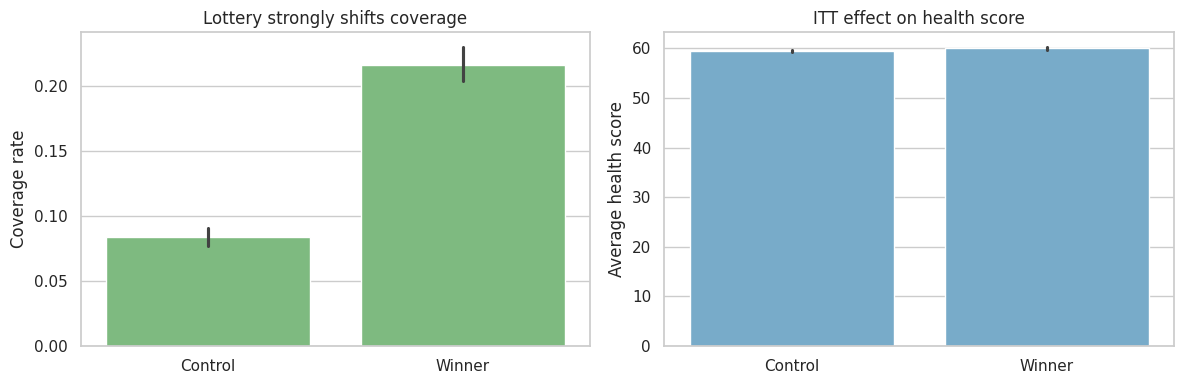

In [10]:
# Build the visualization for the estimates or diagnostics computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=df_health,
    x="lottery",
    y="coverage",
    ax=axes[0],
    color="#74c476",
)
axes[0].set_title("Lottery strongly shifts coverage")
axes[0].set_xticklabels(["Control", "Winner"])
axes[0].set_xlabel("")
axes[0].set_ylabel("Coverage rate")

sns.barplot(
    data=df_health,
    x="lottery",
    y="health_score",
    ax=axes[1],
    color="#6baed6",
)
axes[1].set_title("ITT effect on health score")
axes[1].set_xticklabels(["Control", "Winner"])
axes[1].set_xlabel("")
axes[1].set_ylabel("Average health score")

plt.tight_layout()
plt.show()


The practical takeaway is simple. The estimate matters only after we ask who can receive the program and who might be harmed or excluded.

## 5. Equity Readout for the Lottery

Policy decisions should not stop at the average effect. If enrollment barriers are higher for some groups, the same lottery can produce unequal access.


In [11]:
equity_first_stage = (
    df_health.groupby(["high_barrier", "lottery"])["coverage"]
    .mean()
    .unstack()
    .rename(index={0: "Lower enrollment barrier", 1: "Higher enrollment barrier"})
)
equity_first_stage["first_stage"] = equity_first_stage[1] - equity_first_stage[0]
equity_first_stage


lottery,0,1,first_stage
high_barrier,,,
Lower enrollment barrier,0.083,0.232,0.149
Higher enrollment barrier,0.085,0.175,0.090


The result is useful when it changes what we audit, estimate, or decide. A policy readout should make implementation, take-up, and equity part of the causal interpretation.

In [12]:
equity_itt_rows = []
for group_value, group_df in df_health.groupby("high_barrier"):
    label = "Higher enrollment barrier" if group_value == 1 else "Lower enrollment barrier"
    model = smf.ols(
        "health_score ~ lottery + age + female + chronic + income_pct_fpl + baseline_visits + C(region)",
        data=group_df,
    ).fit(cov_type="HC1")
    row = regression_effect(model, "lottery")
    row["group"] = label
    equity_itt_rows.append(row)

equity_itt = pd.DataFrame(equity_itt_rows).set_index("group")
equity_itt


,estimate,std_error,ci_lower,ci_upper,p_value
group,,,,,
Lower enrollment barrier,0.728,0.166,0.403,1.053,0.000
Higher enrollment barrier,0.330,0.266,-0.190,0.851,0.214


A program can be effective on average while still failing an equity goal. Here, the higher-barrier group receives a smaller first-stage boost, which means the administrative pathway weakens access precisely where support may be needed most.


## 6. Example 2: Education Regression Discontinuity

Now suppose a school district offers intensive tutoring to students whose diagnostic score falls below a cutoff. Students just below the cutoff are eligible; students just above are not.

Regression discontinuity uses the cutoff rule as a source of quasi-experimental variation. The identifying idea is local: students just below and just above the cutoff should be similar except for eligibility.

Lee and Lemieux (2010) describe RD as a design with transparent graphs and concrete assumptions. Wing and Bello-Gomez (2018) emphasize that RD estimates are often highly credible near the cutoff but may not generalize to the entire target population.


In [13]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_tutoring_rd(seed=202, n=6500):
    """Simulate the tutoring rd data-generating process.
    
    Inputs:
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    - `n`: number of simulated units or records to generate for the teaching example.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)
    score_centered = np.clip(rng.normal(0, 18, size=n), -45, 45)
    below_cutoff = (score_centered < 0).astype(int)
    school = rng.choice([f"School {i+1:02d}" for i in range(18)], size=n)
    english_learner = rng.binomial(1, expit(-0.65 - 0.02 * score_centered), size=n)
    prior_attendance = np.clip(rng.normal(0.90 + 0.002 * score_centered - 0.04 * english_learner, 0.05, size=n), 0.60, 1.00)

    tutoring_hours = np.where(
        below_cutoff == 1,
        rng.poisson(22 + 4 * english_learner, size=n),
        rng.poisson(2 + 1 * english_learner, size=n),
    )
    treatment = (tutoring_hours >= 10).astype(int)
    school_effect = {s: rng.normal(0, 1.2) for s in np.unique(school)}

    endline_score = (
        70
        + 0.48 * score_centered
        - 0.010 * score_centered**2 / 10
        + 3.8 * treatment
        + 2.1 * english_learner * treatment
        + 7.0 * (prior_attendance - 0.90)
        + np.array([school_effect[s] for s in school])
        + rng.normal(0, 5.8, size=n)
    )

    return pd.DataFrame(
        {
            "score_centered": score_centered,
            "below_cutoff": below_cutoff,
            "tutoring_hours": tutoring_hours,
            "treatment": treatment,
            "school": school,
            "english_learner": english_learner,
            "prior_attendance": prior_attendance,
            "endline_score": endline_score,
        }
    )


df_rd = simulate_tutoring_rd()
df_rd.head()


,score_centered,below_cutoff,tutoring_hours,treatment,school,english_learner,prior_attendance,endline_score
0,32.611,0,2,0,School 06,0,0.976,91.855
1,-13.123,1,27,1,School 14,0,0.880,60.940
2,-19.541,1,24,1,School 16,0,0.916,64.732
3,-7.234,1,22,1,School 07,0,0.868,63.909
4,-20.747,1,17,1,School 06,0,0.813,75.583


The running variable is the diagnostic score centered at the cutoff. Negative values are below the cutoff and eligible for tutoring.

First inspect the assignment rule.

policy evidence should connect effects to access, compliance, equity, and the population where the recommendation will be used.

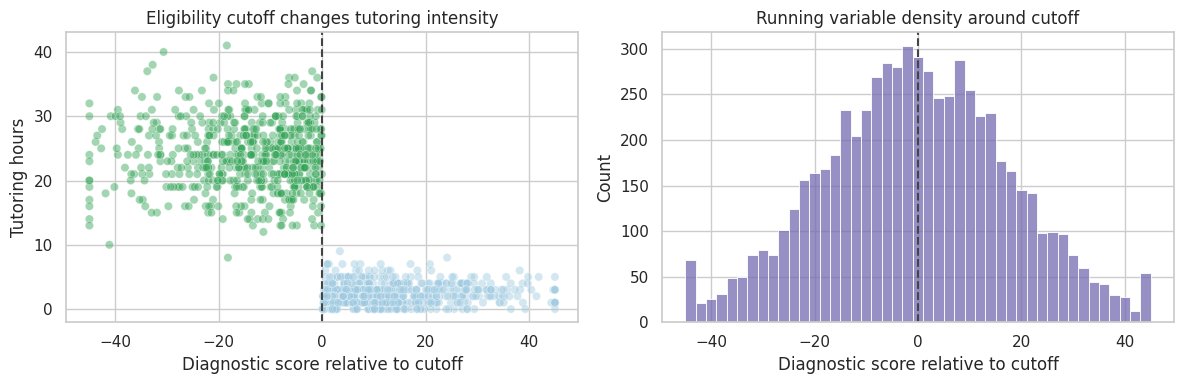

In [14]:
# Build the visualization for the estimates or diagnostics computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    data=df_rd.sample(1200, random_state=4),
    x="score_centered",
    y="tutoring_hours",
    hue="below_cutoff",
    palette={0: "#9ecae1", 1: "#31a354"},
    alpha=0.45,
    ax=axes[0],
    legend=False,
)
axes[0].axvline(0, color="#444444", linestyle="--")
axes[0].set_title("Eligibility cutoff changes tutoring intensity")
axes[0].set_xlabel("Diagnostic score relative to cutoff")
axes[0].set_ylabel("Tutoring hours")

sns.histplot(
    data=df_rd,
    x="score_centered",
    bins=45,
    color="#756bb1",
    ax=axes[1],
)
axes[1].axvline(0, color="#444444", linestyle="--")
axes[1].set_title("Running variable density around cutoff")
axes[1].set_xlabel("Diagnostic score relative to cutoff")

plt.tight_layout()
plt.show()


The histogram is a basic manipulation diagnostic. If families or schools can precisely manipulate the running variable, the density may jump around the cutoff. A visible jump cannot prove manipulation by itself. It demands investigation.


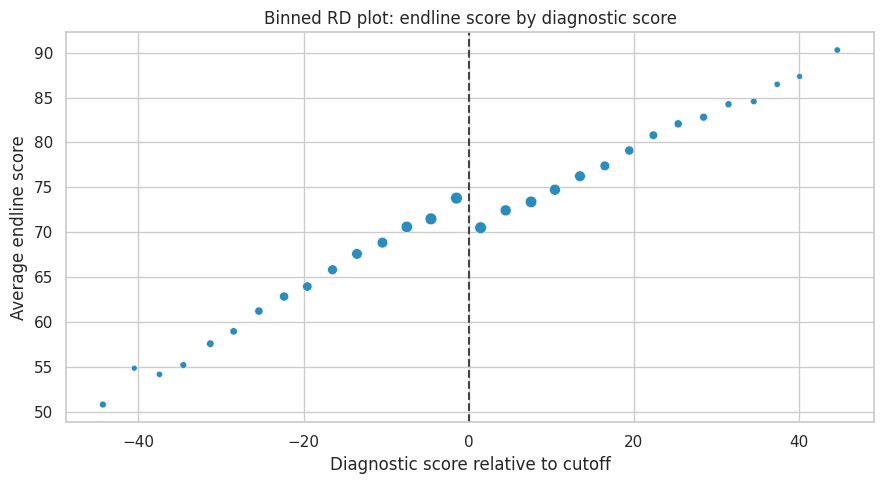

In [15]:
# Build the visualization for the estimates or diagnostics computed above.
df_rd = df_rd.assign(
    score_bin=pd.cut(df_rd["score_centered"], bins=np.arange(-45, 46, 3), include_lowest=True)
)

binned = (
    df_rd.groupby("score_bin")
    .agg(
        score_mid=("score_centered", "mean"),
        endline_score=("endline_score", "mean"),
        tutoring_rate=("treatment", "mean"),
        n=("endline_score", "size"),
    )
    .dropna()
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=binned,
    x="score_mid",
    y="endline_score",
    size="n",
    color="#2b8cbe",
    legend=False,
    ax=ax,
)
ax.axvline(0, color="#444444", linestyle="--")
ax.set_title("Binned RD plot: endline score by diagnostic score")
ax.set_xlabel("Diagnostic score relative to cutoff")
ax.set_ylabel("Average endline score")
plt.tight_layout()
plt.show()


The visual estimand is the jump in the conditional mean of the outcome at the cutoff.

For a sharp RD:

$$
\tau_{RD} =
\lim_{x \downarrow c} E[Y \mid X=x]
-
\lim_{x \uparrow c} E[Y \mid X=x]
$$

Here, treatment intensity changes sharply but not perfectly. For teaching, we will estimate the effect of eligibility using local linear regressions around the cutoff.


In [16]:
def rd_estimate(df, bandwidth):
    """Estimate a local regression-discontinuity treatment effect.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `bandwidth`: distance around the cutoff included in the regression-discontinuity estimate.
    Returns: a pandas Series with the local RD estimate and sample size inside the bandwidth."""
    local = df.loc[df["score_centered"].abs() <= bandwidth].copy()
    model = smf.ols(
        "endline_score ~ below_cutoff + score_centered + below_cutoff:score_centered + english_learner + prior_attendance",
        data=local,
    ).fit(cov_type="HC1")
    out = regression_effect(model, "below_cutoff")
    out["bandwidth"] = bandwidth
    out["n"] = len(local)
    return out


rd_results = pd.DataFrame([rd_estimate(df_rd, bw) for bw in [6, 9, 12, 18, 24]]).set_index("bandwidth")
rd_results


,estimate,std_error,ci_lower,ci_upper,p_value,n
bandwidth,,,,,,
6.000,5.010,0.563,3.907,6.113,0.000,"1,675.000"
9.000,4.479,0.467,3.563,5.394,0.000,"2,485.000"
12.000,4.309,0.410,3.504,5.113,0.000,"3,191.000"
18.000,4.227,0.342,3.556,4.898,0.000,"4,403.000"
24.000,4.387,0.306,3.787,4.988,0.000,"5,272.000"


Bandwidth is a bias-variance choice. Narrow bandwidths compare more similar students but use fewer observations. Wider bandwidths use more data but rely more heavily on functional-form assumptions.

policy evidence should connect effects to access, compliance, equity, and the population where the recommendation will be used.

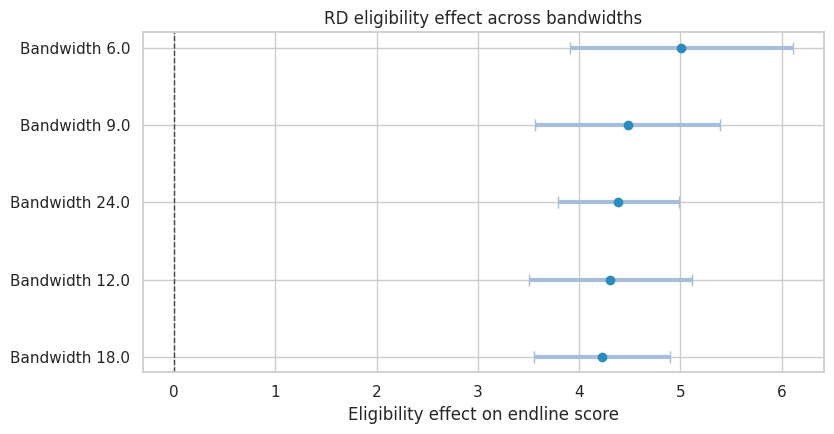

In [17]:
plot_coef_table(
    rd_results.rename(index=lambda x: f"Bandwidth {x}"),
    title="RD eligibility effect across bandwidths",
    xlabel="Eligibility effect on endline score",
    figsize=(8.5, 4.5),
)
plt.show()


The RD estimate should be described precisely:

- It is local to students near the cutoff.
- It estimates the effect of eligibility, not necessarily the effect of every tutoring hour.
- It depends on continuity: absent the program, the outcome trend should have been smooth through the cutoff.
- It is not automatically the right estimate for students far below the cutoff.


In [18]:
rd_equity = []
for group_value, group_df in df_rd.groupby("english_learner"):
    label = "English learner" if group_value == 1 else "Not English learner"
    row = rd_estimate(group_df, 12)
    row["group"] = label
    rd_equity.append(row)

rd_equity = pd.DataFrame(rd_equity).set_index("group")
rd_equity


,estimate,std_error,ci_lower,ci_upper,p_value,bandwidth,n
group,,,,,,,
Not English learner,3.842,0.500,2.862,4.822,0.000,12.000,"2,118.000"
English learner,5.132,0.717,3.727,6.537,0.000,12.000,"1,073.000"


Subgroup RD estimates are often noisy because they use only observations near the cutoff. Still, they can guide implementation questions:

- Does the same eligibility threshold work for all students?
- Are support hours sufficient for students with additional needs?
- Is the program improving average scores while leaving some groups behind?


## 7. Example 3: Staggered Policy Rollout

Now suppose a public health agency rolls out a community care coordination program across counties. The program is intended to reduce preventable emergency visits by connecting high-risk residents to primary care, medication support, transportation assistance, and follow-up.

Counties adopt the program in different quarters. Some counties are not treated during the observation window.

This is a difference-in-differences setting. The key assumption is that, absent treatment, treated and comparison counties would have followed parallel outcome trends. Callaway (2022) reviews DiD for policy evaluation, and Callaway and Sant'Anna (2021) discuss complications with multiple time periods and staggered adoption.


In [19]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_policy_rollout(seed=303, n_counties=72, n_quarters=28):
    """Simulate the policy rollout data-generating process.
    
    Inputs:
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    - `n_counties`: number of policy units in the rollout simulation.
    - `n_quarters`: number of quarterly periods in the policy rollout panel.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)
    counties = [f"County {i+1:02d}" for i in range(n_counties)]
    adoption_options = np.array([10, 14, 18, 999])
    adoption_probs = np.array([0.25, 0.25, 0.25, 0.25])
    adoption_quarter = dict(zip(counties, rng.choice(adoption_options, size=n_counties, p=adoption_probs)))
    deprivation = {c: rng.binomial(1, 0.45) for c in counties}
    county_fe = {c: rng.normal(0, 3.2) + 3.5 * deprivation[c] for c in counties}
    county_trend = {c: rng.normal(0.02, 0.05) for c in counties}

    rows = []
    for county in counties:
        adopt = adoption_quarter[county]
        high_deprivation = deprivation[county]
        for quarter in range(n_quarters):
            treated = int(quarter >= adopt)
            event_time = quarter - adopt if adopt < 900 else np.nan
            seasonal = 1.0 * np.sin(2 * np.pi * quarter / 4)
            secular = -0.06 * quarter
            dynamic_effect = 0
            if treated:
                dynamic_effect = -0.9 - 0.23 * min(max(event_time, 0), 6) - 0.55 * high_deprivation
            outcome = (
                34
                + county_fe[county]
                + seasonal
                + secular
                + county_trend[county] * quarter
                + dynamic_effect
                + rng.normal(0, 1.8)
            )
            program_cost = treated * (1.8 + 0.55 * high_deprivation + rng.normal(0, 0.08))
            rows.append(
                {
                    "county": county,
                    "quarter": quarter,
                    "adoption_quarter": adopt,
                    "treated": treated,
                    "event_time": event_time,
                    "high_deprivation": high_deprivation,
                    "preventable_ed_rate": outcome,
                    "program_cost_per_resident": max(program_cost, 0),
                }
            )

    return pd.DataFrame(rows)


df_policy = simulate_policy_rollout()
df_policy.head()


,county,quarter,adoption_quarter,treated,event_time,high_deprivation,preventable_ed_rate,program_cost_per_resident
0,County 01,0,10,0,-10.000,0,29.885,0.000
1,County 01,1,10,0,-9.000,0,34.583,0.000
2,County 01,2,10,0,-8.000,0,30.227,0.000
3,County 01,3,10,0,-7.000,0,31.381,0.000
4,County 01,4,10,0,-6.000,0,27.667,0.000


This is where the method earns trust from the data. Policy evidence has to connect effects to access, compliance, equity, and the population that will use the recommendation.

In [20]:
rollout_summary = (
    df_policy.drop_duplicates("county")
    .assign(cohort=lambda d: np.where(d["adoption_quarter"] == 999, "Never treated", d["adoption_quarter"].astype(int).astype(str)))
    .groupby(["cohort", "high_deprivation"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Lower deprivation", 1: "Higher deprivation"})
)

rollout_summary


high_deprivation,Lower deprivation,Higher deprivation
cohort,,
10,15,5
14,10,10
18,8,7
Never treated,10,7


First estimate a simple two-way fixed effects model:

$$
Y_{ct} = \alpha_c + \lambda_t + \tau D_{ct} + \epsilon_{ct}
$$

where $c$ indexes county and $t$ indexes quarter.

policy evidence should connect effects to access, compliance, equity, and the population where the recommendation will be used.

In [21]:
twfe_model = smf.ols(
    "preventable_ed_rate ~ treated + C(county) + C(quarter)",
    data=df_policy,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_policy["county"]},
)

twfe_effect = regression_effect(twfe_model, "treated")
twfe_effect


estimate    -2.202
std_error    0.180
ci_lower    -2.555
ci_upper    -1.849
p_value      0.000
dtype: float64

The TWFE coefficient summarizes treated versus untreated county-quarters after county and quarter fixed effects. It is useful as a starting point, but staggered adoption can make this average hard to interpret when treatment effects vary across cohorts or over time.

The event study is the diagnostic workhorse.


In [22]:
# Fit the models for this section and assemble the estimates used in the discussion.
event_window = list(range(-8, 9))
event_window.remove(-1)
event_cols = []

for k in event_window:
    col = f"event_m{abs(k)}" if k < 0 else f"event_p{k}"
    df_policy[col] = ((df_policy["event_time"] == k).astype(int)).fillna(0)
    event_cols.append(col)

event_formula = "preventable_ed_rate ~ " + " + ".join(event_cols) + " + C(county) + C(quarter)"
event_model = smf.ols(event_formula, data=df_policy).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_policy["county"]},
)

event_results = []
for k, col in zip(event_window, event_cols):
    est = event_model.params[col]
    se = event_model.bse[col]
    event_results.append(
        {
            "event_time": k,
            "estimate": est,
            "std_error": se,
            "ci_lower": est - 1.96 * se,
            "ci_upper": est + 1.96 * se,
        }
    )

event_results = pd.DataFrame(event_results)
event_results.head()


,event_time,estimate,std_error,ci_lower,ci_upper
0,-8,0.973,0.340,0.306,1.640
1,-7,0.570,0.349,-0.114,1.253
2,-6,0.471,0.310,-0.137,1.080
3,-5,0.866,0.262,0.353,1.380
4,-4,0.926,0.345,0.250,1.603


The point is to connect the number to the decision it supports. The estimate matters only after we ask who can receive the program and who might be harmed or excluded.

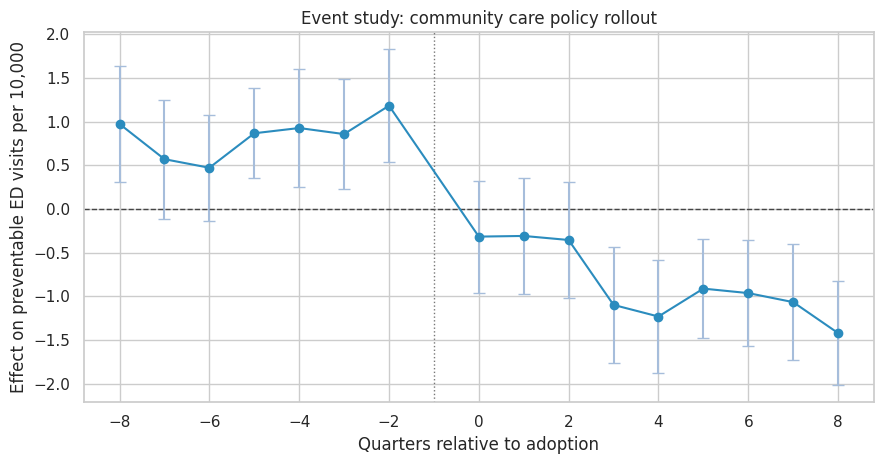

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.8))

ax.errorbar(
    event_results["event_time"],
    event_results["estimate"],
    yerr=[
        event_results["estimate"] - event_results["ci_lower"],
        event_results["ci_upper"] - event_results["estimate"],
    ],
    fmt="o-",
    color="#2b8cbe",
    ecolor="#a6bddb",
    capsize=4,
)
ax.axhline(0, color="#444444", linestyle="--", linewidth=1)
ax.axvline(-1, color="#777777", linestyle=":", linewidth=1)
ax.set_title("Event study: community care policy rollout")
ax.set_xlabel("Quarters relative to adoption")
ax.set_ylabel("Effect on preventable ED visits per 10,000")
plt.tight_layout()
plt.show()


A credible event study should show no strong pre-treatment differences in the periods before adoption. Post-treatment coefficients should move after, not before, the policy begins.

In this simulation the post-treatment effect becomes more negative over time, which is plausible for a coordination program that takes time to change utilization.


In [24]:
heterogeneity_model = smf.ols(
    "preventable_ed_rate ~ treated + treated:high_deprivation + C(county) + C(quarter)",
    data=df_policy,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_policy["county"]},
)

heterogeneity_table = pd.DataFrame(
    {
        "Base treated effect": regression_effect(heterogeneity_model, "treated"),
        "Additional effect in high-deprivation counties": regression_effect(heterogeneity_model, "treated:high_deprivation"),
    }
).T

heterogeneity_table


,estimate,std_error,ci_lower,ci_upper,p_value
Base treated effect,-2.128,0.201,-2.521,-1.734,0.000
Additional effect in high-deprivation counties,-0.185,0.255,-0.684,0.315,0.469


The interaction term asks whether the effect differs in higher-deprivation counties. In policy work, this is not a decorative subgroup analysis. It is central to whether a program is reducing or widening inequity.


In [25]:
# Fit the models for this section and assemble the estimates used in the discussion.
cost_effect_model = smf.ols(
    "program_cost_per_resident ~ treated + C(county) + C(quarter)",
    data=df_policy,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_policy["county"]},
)

ed_effect = twfe_effect["estimate"]
cost_effect = regression_effect(cost_effect_model, "treated")["estimate"]
assumed_cost_per_preventable_ed_visit = 1200
residents_per_county = 100000

avoided_visits_per_county_quarter = -ed_effect * residents_per_county / 10000
gross_savings = avoided_visits_per_county_quarter * assumed_cost_per_preventable_ed_visit
program_cost = cost_effect * residents_per_county
net_savings = gross_savings - program_cost

cost_readout = pd.Series(
    {
        "ED rate effect per 10,000 residents": ed_effect,
        "Avoided visits per county-quarter": avoided_visits_per_county_quarter,
        "Gross avoided ED cost per county-quarter": gross_savings,
        "Program cost per county-quarter": program_cost,
        "Net savings per county-quarter": net_savings,
    }
)

cost_readout


ED rate effect per 10,000 residents              -2.202
Avoided visits per county-quarter                22.020
Gross avoided ED cost per county-quarter     26,424.142
Program cost per county-quarter             201,989.251
Net savings per county-quarter             -175,565.109
dtype: float64

Cost-effectiveness calculations should be transparent about assumptions. Here the dollar value depends on an assumed cost per preventable emergency visit and a stylized county size. In real policy work, the analyst would show sensitivity ranges.


In [26]:
cost_sensitivity = []
for ed_cost in [800, 1000, 1200, 1600, 2000]:
    gross = avoided_visits_per_county_quarter * ed_cost
    cost_sensitivity.append(
        {
            "assumed_cost_per_avoided_visit": ed_cost,
            "gross_savings": gross,
            "program_cost": program_cost,
            "net_savings": gross - program_cost,
        }
    )

cost_sensitivity = pd.DataFrame(cost_sensitivity)
cost_sensitivity


,assumed_cost_per_avoided_visit,gross_savings,program_cost,net_savings
0,800,"17,616.095","201,989.251","-184,373.156"
1,1000,"22,020.118","201,989.251","-179,969.133"
2,1200,"26,424.142","201,989.251","-175,565.109"
3,1600,"35,232.189","201,989.251","-166,757.062"
4,2000,"44,040.237","201,989.251","-157,949.014"


Here the example becomes operational. A policy readout should make implementation, take-up, and equity part of the causal interpretation.

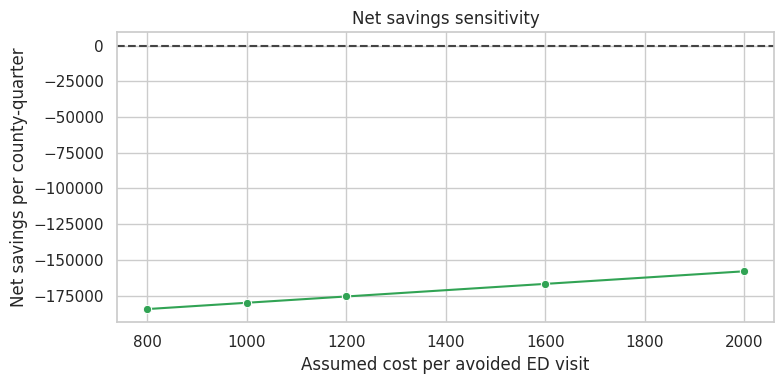

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(
    data=cost_sensitivity,
    x="assumed_cost_per_avoided_visit",
    y="net_savings",
    marker="o",
    color="#31a354",
    ax=ax,
)
ax.axhline(0, color="#444444", linestyle="--")
ax.set_title("Net savings sensitivity")
ax.set_xlabel("Assumed cost per avoided ED visit")
ax.set_ylabel("Net savings per county-quarter")
plt.tight_layout()
plt.show()


This output should make the next modeling choice easier to defend. Policy evidence has to connect effects to access, compliance, equity, and the population that will use the recommendation.

## 8. Evidence to Decision: Three Different Answers

A policy leader may ask, "Does this work?" The honest answer often has layers.


| question | design | estimand | answer_style |
|---|---|---|---|
| Did program access matter? | Lottery or randomized encouragement | ITT | Effect of offering access under real implementation. |
| Did actual treatment matter for those induced to participate? | Instrumental variables | LATE | Effect for compliers, not necessarily everyone. |
| Did an eligibility threshold change outcomes? | Regression discontinuity | Local effect at cutoff | Highly local answer around the threshold. |
| Did a rolled-out policy change outcomes over time? | Difference-in-differences or event study | ATT for treated units over observed rollout | Depends on parallel trends and credible comparison groups. |
| Should we scale? | Decision analysis | Expected net value with equity and implementation risk | Combines causal evidence, cost, feasibility, and ethics. |


## 9. Policy Decision Memo

The memo should not overstate evidence. It should separate the causal estimate from the implementation recommendation.


In [29]:
ed_ci_lower = twfe_effect["ci_lower"]
ed_ci_upper = twfe_effect["ci_upper"]
equity_extra = heterogeneity_table.loc["Additional effect in high-deprivation counties", "estimate"]

recommendation = "Scale with staged monitoring" if (ed_effect < 0 and net_savings > 0) else "Continue pilot before scaling"

memo = f'''
### Policy Evaluation Decision Memo

**Policy:** community care coordination rollout across counties.

**Design:** staggered difference-in-differences with county and quarter fixed effects, supported by event-study diagnostics.

**Primary effect:** the policy changed preventable emergency visits by **{ed_effect:,.2f}** per 10,000 residents
with a 95% confidence interval from **{ed_ci_lower:,.2f}** to **{ed_ci_upper:,.2f}**.
Negative values indicate fewer preventable visits.

**Equity readout:** the additional effect in higher-deprivation counties was **{equity_extra:,.2f}** per 10,000 residents.
This suggests the program may deliver larger gains in counties with higher baseline need, but subgroup estimates should be monitored as rollout expands.

**Economic readout:** under the assumed avoided-visit cost of **${assumed_cost_per_preventable_ed_visit:,.0f}**, estimated net savings are
**${net_savings:,.0f}** per county-quarter.

**Recommendation:** **{recommendation}.**

**Conditions:** preserve a holdout or delayed-rollout comparison group where feasible, track implementation fidelity, report subgroup outcomes, and update the cost-effectiveness model with observed program costs.
'''

display(Markdown(memo))



### Policy Evaluation Decision Memo

**Policy:** community care coordination rollout across counties.

**Design:** staggered difference-in-differences with county and quarter fixed effects, supported by event-study diagnostics.

**Primary effect:** the policy changed preventable emergency visits by **-2.20** per 10,000 residents
with a 95% confidence interval from **-2.55** to **-1.85**.
Negative values indicate fewer preventable visits.

**Equity readout:** the additional effect in higher-deprivation counties was **-0.18** per 10,000 residents.
This suggests the program may deliver larger gains in counties with higher baseline need, but subgroup estimates should be monitored as rollout expands.

**Economic readout:** under the assumed avoided-visit cost of **$1,200**, estimated net savings are
**$-175,565** per county-quarter.

**Recommendation:** **Continue pilot before scaling.**

**Conditions:** preserve a holdout or delayed-rollout comparison group where feasible, track implementation fidelity, report subgroup outcomes, and update the cost-effectiveness model with observed program costs.


## 10. Common Pitfalls in Health, Education, and Policy Work

- **Confusing access with treatment:** assignment, eligibility, enrollment, attendance, and completion are different variables.
- **Conditioning on post-treatment variables:** for example, analyzing only patients who visit a clinic after coverage changes access to clinics.
- **Ignoring implementation:** a weak ITT may mean the program is ineffective, or it may mean the program did not reach people.
- **Overgeneralizing local effects:** RD estimates near the cutoff do not automatically apply to people far from the cutoff.
- **Ignoring staggered DiD complications:** with heterogeneous effects, simple TWFE can be hard to interpret.
- **Under-reporting harms:** average gains can hide worse outcomes for a subgroup.
- **Treating cost as an afterthought:** policy decisions need value, not just statistical significance.


## 11. Exercises

1. In the health lottery simulation, reduce enrollment among the higher-barrier group. How do ITT, first stage, and LATE change?
2. Add an exclusion restriction violation to the lottery simulation by letting lottery winners receive navigation help even without coverage. What happens to the IV interpretation?
3. In the tutoring RD simulation, create manipulation around the cutoff by moving some students just below zero. How does the histogram change?
4. Estimate the tutoring effect using a much wider bandwidth. Why can the result change?
5. In the policy rollout simulation, make early-adopting counties have improving pre-trends. What does the event study reveal?
6. Build a decision memo that recommends against scaling even when the primary causal effect is positive. Which guardrail or cost assumption drives the recommendation?


## 12. Key Takeaways

- Policy evaluation starts with a decision, but it should not let the desired decision define the evidence.
- Lotteries identify ITT effects cleanly; actual treatment effects require compliance logic.
- Instrumental variables estimate a local effect for compliers under assumptions such as relevance, exclusion, monotonicity, and as-if random assignment.
- Regression discontinuity can be highly credible near a cutoff, but it is local.
- Difference-in-differences can evaluate staggered policy rollouts, but pre-trends, comparison groups, and heterogeneous effects matter.
- Health, education, and policy readouts should include equity, cost, implementation fidelity, and uncertainty.


## References

Angrist, J. D., Imbens, G. W., & Rubin, D. B. (1996). Identification of causal effects using instrumental variables. *Journal of the American Statistical Association, 91*(434), 444-455. https://doi.org/10.1080/01621459.1996.10476902

Baicker, K., Taubman, S. L., Allen, H. L., Bernstein, M., Gruber, J. H., Newhouse, J. P., Schneider, E. C., Wright, B. J., Zaslavsky, A. M., & Finkelstein, A. N. (2013). The Oregon experiment - effects of Medicaid on clinical outcomes. *New England Journal of Medicine, 368*(18), 1713-1722. https://doi.org/10.1056/NEJMsa1212321

Callaway, B. (2022). Difference-in-differences for policy evaluation. *arXiv*. https://doi.org/10.48550/arxiv.2203.15646

Callaway, B., & Sant'Anna, P. H. C. (2021). Difference-in-differences with multiple time periods. *Journal of Econometrics, 225*(2), 200-230. https://doi.org/10.1016/j.jeconom.2020.12.001

Deaton, A., & Cartwright, N. (2018). Understanding and misunderstanding randomized controlled trials. *Social Science & Medicine, 210*, 2-21. https://doi.org/10.1016/j.socscimed.2017.12.005

Imbens, G. W. (2014). Instrumental variables: An econometrician's perspective. *Statistical Science, 29*(3), 323-358. https://doi.org/10.1214/14-STS480

Lee, D. S., & Lemieux, T. (2010). Regression discontinuity designs in economics. *Journal of Economic Literature, 48*(2), 281-355. https://doi.org/10.1257/jel.48.2.281

Wing, C., & Bello-Gomez, R. A. (2018). Regression discontinuity and beyond. *American Journal of Evaluation, 39*(1), 91-108. https://doi.org/10.1177/1098214017736155
